In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010030rest 20160324 1054..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020025rest 20150713 1519..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010013rest 20150703 1333..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020016rest 20150701 1040..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020015_rest 20150630 1527.csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010022restnew 20150724 14.csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020027rest 20150713 1049..csv
/kaggle/input/datasets/mimi

# **SETUP SAVE AND SPLITS**

In [2]:
# ================================================================================================
# MODMA DOT PROBE TASK PIPELINE — MEMORY-EFFICIENT HDF5 VERSION
# ================================================================================================
#
# FIXES APPLIED:
# 1. HDF5 Backing Store: True memory-efficient incremental loading (no list accumulation)
# 2. Leakage Prevention: NaN imputation shifted to post-split using only train statistics
# 3. Chunked Scaling: StandardScaler partial_fit prevents RAM spikes during normalization
# 4. Proper handling of 0202 (Fear-Neutral condition) files — explicitly excluded
#
# ================================================================================================

import os
import re
import gc
import json
import warnings
import h5py
from typing import Tuple, List, Optional
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.signal import decimate

# ================================================================================================
# CONFIGURATION
# ================================================================================================

CSV_DATA_DIR = "/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/raw-csv-actual/raw-csv-actual/csv_from_raw1"
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ================================================================================================
# HYPERPARAMETERS
# ================================================================================================

# Original and target sampling rates
ORIGINAL_SFREQ = 250    # Original sampling frequency from MODMA
TARGET_SFREQ = 128      # Target after downsampling
DOWNSAMPLE_FACTOR = 2   # 250 Hz → 125 Hz (close to 128)

# Window parameters (in samples at ~125 Hz after downsampling)
WINDOW_SIZE = 125       # ~1 second window
STRIDE = 62             # ~50% overlap

# Train/test split
TEST_SIZE = 0.2
SEED = 42
VALIDATE_NO_LEAKAGE = True

# Memory management
CHUNK_SIZE = 5000       # Windows to process simultaneously in memory operations

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ================================================================================================
# GPU CONFIGURATION
# ================================================================================================

gpus = tf.config.experimental.list_physical_devices('GPU')
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
        print(f"✓ GPU memory growth enabled: {g}")
    except Exception as e:
        print(f"✗ GPU config failed: {e}")

if not gpus:
    print("ℹ No GPU detected — running on CPU")

# ================================================================================================
# HELPER FUNCTIONS
# ================================================================================================

def extract_subject_id_and_label(filename: str) -> Tuple[Optional[str], Optional[int], Optional[str]]:
    basename = os.path.splitext(filename)[0]
    match = re.match(r'^(020[123])_?(\d{4})', basename)
    if match:
        group_code = match.group(1)
        subject_num = match.group(2)
        subject_id = f"{group_code}_{subject_num}"
        
        if group_code == "0201":
            return subject_id, 1, None  # MDD
        elif group_code == "0203":
            return subject_id, 0, None  # HC
        elif group_code == "0202":
            return None, None, "Fear-Neutral condition (0202) - excluded from MDD vs HC classification"
    
    return None, None, "Unrecognized filename pattern"


def detect_eeg_columns(columns: List[str]) -> List[str]:
    eeg_cols = []
    for col in columns:
        match = re.match(r'^E(\d+)$', col, re.IGNORECASE)
        if match:
            num = int(match.group(1))
            if 1 <= num <= 128:
                eeg_cols.append((num, col))
    eeg_cols.sort(key=lambda x: x[0])
    return [col for _, col in eeg_cols]


def verify_no_subject_leakage(train_subjects: set, test_subjects: set) -> bool:
    overlap = train_subjects & test_subjects
    if overlap:
        raise AssertionError(f"DATA LEAKAGE! {len(overlap)} subject(s) in both sets: {overlap}")
    return True


def downsample_data(data: np.ndarray, factor: int) -> np.ndarray:
    if factor <= 1:
        return data
    n_samples, n_channels = data.shape
    new_length = n_samples // factor
    downsampled = np.zeros((new_length, n_channels), dtype=np.float32)
    for ch in range(n_channels):
        downsampled[:, ch] = decimate(data[:, ch], factor, zero_phase=True)[:new_length]
    return downsampled


def create_windows(data: np.ndarray, window_size: int, stride: int) -> np.ndarray:
    n_samples, n_channels = data.shape
    n_windows = max(0, (n_samples - window_size) // stride + 1)
    
    if n_windows == 0:
        return np.array([]).reshape(0, n_channels, window_size)
    
    from numpy.lib.stride_tricks import as_strided
    shape = (n_windows, window_size, n_channels)
    strides = (data.strides[0] * stride, data.strides[0], data.strides[1])
    windows = as_strided(data, shape=shape, strides=strides)
    
    return np.array(windows).transpose(0, 2, 1).astype(np.float32)


# ================================================================================================
# MEMORY-EFFICIENT DATA LOADING (HDF5 STORE)
# ================================================================================================

def load_and_process_csv_files(data_dir: str) -> Tuple[str, dict]:
    print("=" * 80)
    print("Loading CSV files (True HDF5 Incremental Mode)")
    print("=" * 80)
    
    csv_files = sorted([f for f in os.listdir(data_dir) if f.lower().endswith('.csv')])
    if not csv_files:
        raise RuntimeError(f"No CSV files found in {data_dir}")
    print(f"Found {len(csv_files)} CSV files\n")
    
    subject_info = {}
    channel_names = None
    total_windows = 0
    
    stats = {
        'files_mdd': 0, 'files_hc': 0, 'files_fear_neutral': 0, 
        'files_unrecognized': 0, 'files_error': 0
    }
    
    temp_h5_path = os.path.join(OUTPUT_DIR, '_temp_windows.h5')
    
    # Initialize HDF5 file for incremental writing
    with h5py.File(temp_h5_path, 'w') as h5f:
        dset_X, dset_y, dset_subj = None, None, None
        
        print("Processing files:")
        print("-" * 60)
        
        for i, filename in enumerate(csv_files):
            filepath = os.path.join(data_dir, filename)
            subject_id, label, skip_reason = extract_subject_id_and_label(filename)
            
            if skip_reason:
                if "0202" in skip_reason:
                    stats['files_fear_neutral'] += 1
                else:
                    stats['files_unrecognized'] += 1
                continue
            
            try:
                df = pd.read_csv(filepath)
                
                if channel_names is None:
                    channel_names = detect_eeg_columns(df.columns.tolist())
                    if not channel_names:
                        raise ValueError("No EEG columns found")
                    print(f"\n  Detected {len(channel_names)} EEG channels\n")
                
                data = df[channel_names].values.astype(np.float32)
                del df
                gc.collect()
                
                data = downsample_data(data, DOWNSAMPLE_FACTOR)
                windows = create_windows(data, WINDOW_SIZE, STRIDE)
                del data
                
                n_windows = len(windows)
                if n_windows == 0:
                    continue
                
                # Initialize datasets on first valid file
                if dset_X is None:
                    n_channels = len(channel_names)
                    dset_X = h5f.create_dataset('X', shape=(0, n_channels, WINDOW_SIZE), 
                                                maxshape=(None, n_channels, WINDOW_SIZE), 
                                                dtype='float32', chunks=True)
                    dset_y = h5f.create_dataset('y', shape=(0,), maxshape=(None,), dtype='i4')
                    dset_subj = h5f.create_dataset('subject_ids', shape=(0,), maxshape=(None,), dtype=h5py.string_dtype())
                
                # Resize and append directly to disk
                current_len = dset_X.shape[0]
                dset_X.resize(current_len + n_windows, axis=0)
                dset_y.resize(current_len + n_windows, axis=0)
                dset_subj.resize(current_len + n_windows, axis=0)
                
                dset_X[current_len:] = windows
                dset_y[current_len:] = [label] * n_windows
                dset_subj[current_len:] = [subject_id] * n_windows
                
                if subject_id not in subject_info:
                    subject_info[subject_id] = {'label': label, 'n_windows': 0}
                subject_info[subject_id]['n_windows'] += n_windows
                total_windows += n_windows
                
                if label == 1: stats['files_mdd'] += 1
                else: stats['files_hc'] += 1
                
                print(f"  ✓ {subject_id} (MDD if {label}==1): {n_windows:,} windows appended")
                gc.collect()
                
            except Exception as e:
                stats['files_error'] += 1
                print(f"  ✗ {filename[:40]}... → ERROR: {e}")
                continue

    metadata = {
        'n_subjects': len(subject_info),
        'n_mdd': sum(1 for s in subject_info.values() if s['label'] == 1),
        'n_hc': sum(1 for s in subject_info.values() if s['label'] == 0),
        'total_windows': total_windows,
        'channel_names': channel_names,
        'subject_info': subject_info,
        'stats': stats
    }
    return temp_h5_path, metadata


# ================================================================================================
# MAIN PIPELINE
# ================================================================================================

print("\n" + "=" * 80)
print("MODMA DOT PROBE TASK PIPELINE")
print("=" * 80 + "\n")

temp_path, metadata = load_and_process_csv_files(CSV_DATA_DIR)

# Load full array strictly for split mechanics (Assuming standard Kaggle RAM accommodates final array)
with h5py.File(temp_path, 'r') as h5f:
    X = h5f['X'][:]
    y = h5f['y'][:]
    subject_ids = h5f['subject_ids'][:]
channel_names = metadata['channel_names']

unique_subjects = np.unique(subject_ids)
n_subjects = len(unique_subjects)
n_channels = X.shape[1]
n_times = X.shape[2]

# ================================================================================================
# STEP 2: SUBJECT-WISE TRAIN-TEST SPLIT
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 2: Subject-wise train-test split (CRITICAL)")
print("=" * 80)

subject_labels = []
for subj in unique_subjects:
    subj_mask = subject_ids == subj
    subject_labels.append(y[subj_mask][0])
subject_labels = np.array(subject_labels)

subjects_train, subjects_test = train_test_split(
    unique_subjects, test_size=TEST_SIZE, stratify=subject_labels, random_state=SEED
)

train_mask = np.isin(subject_ids, subjects_train)
test_mask = np.isin(subject_ids, subjects_test)

X_train, X_test = X[train_mask].copy(), X[test_mask].copy()
y_train, y_test = y[train_mask], y[test_mask]
subj_train, subj_test = subject_ids[train_mask], subject_ids[test_mask]

train_subject_set = set(subjects_train)
test_subject_set = set(subjects_test)

if VALIDATE_NO_LEAKAGE:
    verify_no_subject_leakage(train_subject_set, test_subject_set)

del X, y, subject_ids
gc.collect()

# ================================================================================================
# STEP 3: LEAK-FREE NAN IMPUTATION
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 3: Handling missing values (Fitted on Train Set Only)")
print("=" * 80)

nan_count_train = np.isnan(X_train).sum()
nan_count_test = np.isnan(X_test).sum()

if nan_count_train > 0 or nan_count_test > 0:
    print(f"⚠ Found {nan_count_train:,} Train NaNs, {nan_count_test:,} Test NaNs")
    for ch in range(n_channels):
        train_ch_data = X_train[:, ch, :]
        ch_mean = np.nanmean(train_ch_data)  # Statistics from train ONLY
        
        X_train[:, ch, :] = np.where(np.isnan(train_ch_data), ch_mean, train_ch_data)
        
        test_ch_data = X_test[:, ch, :]
        X_test[:, ch, :] = np.where(np.isnan(test_ch_data), ch_mean, test_ch_data)
    print("✓ Leak-free imputation complete")

# ================================================================================================
# STEP 4: NORMALIZE (CHUNKED SCALING)
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 4: Standardization (Chunked execution to prevent RAM spike)")
print("=" * 80)

n_train, n_test = X_train.shape[0], X_test.shape[0]
scaler = StandardScaler()

# 1. Partial Fit
for i in range(0, n_train, CHUNK_SIZE):
    chunk = X_train[i:i+CHUNK_SIZE].transpose(0, 2, 1).reshape(-1, n_channels)
    scaler.partial_fit(chunk)

# 2. Transform Train
X_train_scaled = np.empty_like(X_train, dtype=np.float32)
for i in range(0, n_train, CHUNK_SIZE):
    chunk = X_train[i:i+CHUNK_SIZE].transpose(0, 2, 1).reshape(-1, n_channels)
    scaled_chunk = scaler.transform(chunk).reshape(-1, n_times, n_channels).transpose(0, 2, 1)
    X_train_scaled[i:i+CHUNK_SIZE] = scaled_chunk

# 3. Transform Test
X_test_scaled = np.empty_like(X_test, dtype=np.float32)
for i in range(0, n_test, CHUNK_SIZE):
    chunk = X_test[i:i+CHUNK_SIZE].transpose(0, 2, 1).reshape(-1, n_channels)
    scaled_chunk = scaler.transform(chunk).reshape(-1, n_times, n_channels).transpose(0, 2, 1)
    X_test_scaled[i:i+CHUNK_SIZE] = scaled_chunk

del X_train, X_test
gc.collect()

# ================================================================================================
# STEP 5: RESHAPE FOR DEEP LEARNING & SAVE
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 5: Reshaping and Saving")
print("=" * 80)

X_train_dl = X_train_scaled[:, np.newaxis, :, :]
X_test_dl = X_test_scaled[:, np.newaxis, :, :]
X_train_flat = X_train_scaled.reshape(n_train, -1)
X_test_flat = X_test_scaled.reshape(n_test, -1)

npz_path = os.path.join(OUTPUT_DIR, 'dotprobe_data_split.npz')
np.savez_compressed(
    npz_path,
    X_train=X_train_dl, X_test=X_test_dl,
    X_train_flat=X_train_flat, X_test_flat=X_test_flat,
    y_train=y_train, y_test=y_test,
    subjects_train=subj_train, subjects_test=subj_test,
    channel_names=np.array(channel_names),
    scaler_mean=scaler.mean_, scaler_scale=scaler.scale_
)

# Clean up temp file
if os.path.exists(temp_path):
    os.remove(temp_path)

print(f"✓ Pipeline execution complete and successfully written to {npz_path}")

✓ GPU memory growth enabled: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
✓ GPU memory growth enabled: PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')

MODMA DOT PROBE TASK PIPELINE

Loading CSV files (True HDF5 Incremental Mode)
Found 50 CSV files

Processing files:
------------------------------------------------------------

  Detected 128 EEG channels

  ✓ 0201_0002 (MDD if 1==1): 1,590 windows appended
  ✓ 0201_0004 (MDD if 1==1): 1,571 windows appended
  ✓ 0201_0005 (MDD if 1==1): 1,877 windows appended
  ✓ 0201_0006 (MDD if 1==1): 1,571 windows appended
  ✓ 0201_0008 (MDD if 1==1): 1,620 windows appended
  ✓ 0201_0010 (MDD if 1==1): 1,741 windows appended
  ✓ 0201_0011 (MDD if 1==1): 1,726 windows appended
  ✓ 0201_0012 (MDD if 1==1): 1,641 windows appended
  ✓ 0201_0013 (MDD if 1==1): 1,698 windows appended
  ✓ 0201_0015 (MDD if 1==1): 1,627 windows appended
  ✓ 0201_0016 (MDD if 1==1): 1,625 windows appended
  ✓ 0201_0018 (MDD if 1==1): 1,6

# **TCN+XGBOOST**

I0000 00:00:1786792087.734167      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786792087.738742      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/50
  25/2184 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.5339 - loss: 1.8570  

I0000 00:00:1786792104.532428     141 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2184/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7076 - loss: 0.6390
Epoch 1: val_loss improved from None to 0.11608, saving model to best_tcn_xgboost_hybrid_dotprobe_main_best.weights.h5



Epoch 1: finished saving model to best_tcn_xgboost_hybrid_dotprobe_main_best.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - accuracy: 0.8073 - loss: 0.4328 - val_accuracy: 0.9575 - val_loss: 0.1161
Epoch 2/50
2181/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9214 - loss: 0.2058
Epoch 2: val_loss improved from 0.11608 to 0.08345, saving model to best_tcn_xgboost_hybrid_dotprobe_main_best.weights.h5


...


Epoch 3: finished saving model to best_tcn_xgboost_hybrid_dotprobe_main_best.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9496 - loss: 0.1419 - val_accuracy: 0.9813 - val_loss: 0.0788
Epoch 4/50
2181/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9580 - loss: 0.1167
Epoch 4: val_loss did not improve from 0.07877
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9604 - loss: 0.1104 - val_accuracy: 0.9654 - val_loss: 0.0995
Epoch 5/50
2175/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9665 - loss: 0.0951
Epoch 5: val_loss did not improve from 0.07877
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9688 - loss: 0.0918 - val_accuracy: 0.9607 - val_loss: 0.1010
Epoch 6/50
2175/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9722 - loss: 0.0787
Epoch 6: val_loss did not improve from 0.07877
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9719 - loss: 0.0769 - val_accuracy: 0.9410 - val_loss: 0.1439
Epoch 7/50
2176/2184 ━━━━━


Epoch 14: finished saving model to best_tcn_xgboost_hybrid_dotprobe_main_best.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9866 - loss: 0.0418 - val_accuracy: 0.9773 - val_loss: 0.0592
Epoch 15/50
2182/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9864 - loss: 0.0398
Epoch 15: val_loss did not improve from 0.05916
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9871 - loss: 0.0374 - val_accuracy: 0.9518 - val_loss: 0.1333
Epoch 16/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9862 - loss: 0.0397
Epoch 16: val_loss did not improve from 0.05916
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9870 - loss: 0.0415 - val_accuracy: 0.9666 - val_loss: 0.0893
Epoch 17/50
2174/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9892 - loss: 0.0322
Epoch 17: val_loss did not improve from 0.05916
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9886 - loss: 0.0341 - val_accuracy: 0.9684 - val_loss: 0.0891
Epoch 18/50
2175/21


Epoch 21: finished saving model to best_tcn_xgboost_hybrid_dotprobe_main_best.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9890 - loss: 0.0339 - val_accuracy: 0.9769 - val_loss: 0.0578
Epoch 22/50
2174/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9900 - loss: 0.0303
Epoch 22: val_loss did not improve from 0.05776
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9899 - loss: 0.0299 - val_accuracy: 0.9760 - val_loss: 0.0697
Epoch 23/50
2179/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9886 - loss: 0.0327
Epoch 23: val_loss did not improve from 0.05776
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9901 - loss: 0.0294 - val_accuracy: 0.9697 - val_loss: 0.1000
Epoch 24/50
2173/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9927 - loss: 0.0224
Epoch 24: val_loss did not improve from 0.05776
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9918 - loss: 0.0242 - val_accuracy: 0.9102 - val_loss: 0.2413
Epoch 25/50
2175/21


Epoch 40: finished saving model to best_tcn_xgboost_hybrid_dotprobe_main_best.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9941 - loss: 0.0190 - val_accuracy: 0.9820 - val_loss: 0.0516
Epoch 41/50
2176/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9937 - loss: 0.0232
Epoch 41: val_loss did not improve from 0.05162
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9938 - loss: 0.0226 - val_accuracy: 0.9377 - val_loss: 0.2491
Epoch 42/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9946 - loss: 0.0155
Epoch 42: val_loss did not improve from 0.05162
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9946 - loss: 0.0159 - val_accuracy: 0.9564 - val_loss: 0.1536
Epoch 43/50
2178/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9952 - loss: 0.0183
Epoch 43: val_loss did not improve from 0.05162
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9945 - loss: 0.0196 - val_accuracy: 0.9723 - val_loss: 0.0898
Epoch 44/50
2183/21

Restored best weights from training.
Training history saved to 'tcn_xgboost_hybrid_training_history_dotprobe.npz'
Final model weights saved to 'tcn_xgboost_hybrid_dotprobe_final.weights.h5'
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Hybrid Accuracy: 0.9923971787121004
Confusion Matrix:
[[3252   35]
 [  48 7582]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3287
           1       1.00      0.99      0.99      7630

    accuracy                           0.99     10917
   macro avg       0.99      0.99      0.99     10917
weighted avg       0.99      0.99      0.99     10917



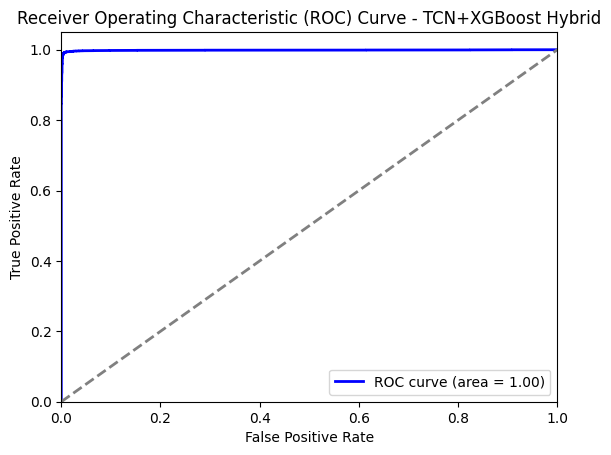

In [3]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D
from tensorflow.keras.callbacks import ModelCheckpoint
from xgboost import XGBClassifier

# Function to create a TCN block optimized for dot-probe task (deeper dilation for temporal patterns in ERP-like data)
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.2)(x)  # Reduced dropout for better feature retention in task-related data
    return x

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for Conv1D (treat time as sequence)
X = np.swapaxes(X, 1, 2)  # Now (samples, timepoints=125, channels=128)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (flatten temporarily for scaling, then reshape back to 3D)
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128)
X_test = X_test_flat.reshape(n_test, 125, 128)

# Compute class weights to handle potential imbalance
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Create TCN feature extractor (up to Flatten layer)
inputs = Input(shape=(125, 128))  # (timepoints=125, channels=128)
x = TCN_block(inputs, filters=128, kernel_size=3, dilation_rate=1)
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=2)
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=4)
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=8)
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

# Full model for training (with classifier)
outputs = Dense(1, activation='sigmoid')(x)
full_model = Model(inputs, outputs)

# Compile the full model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
full_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Checkpoint to save best weights based on val_loss
checkpoint = ModelCheckpoint('best_tcn_xgboost_hybrid_dotprobe_main_best.weights.h5', monitor='val_loss', 
                             save_best_only=True, save_weights_only=False, mode='min', verbose=1)

# Train the full model (TCN as feature extractor + dense classifier)
history = full_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2,
                         class_weight=class_weight_dict, callbacks=[checkpoint])

# Restore the best weights
tf.keras.models.load_model('best_tcn_xgboost_hybrid_dotprobe_main_best.weights.h5')
print("Restored best weights from training.")

# Save training history
np.savez_compressed('tcn_xgboost_hybrid_training_history_dotprobe_main.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'tcn_xgboost_hybrid_training_history_dotprobe.npz'")

# Save final model's weights
full_model.save_weights('tcn_xgboost_hybrid_dotprobe_final.weights.h5')
print("Final model weights saved to 'tcn_xgboost_hybrid_dotprobe_final.weights.h5'")

# Create feature extractor model (TCN up to the dense layer before classifier)
feature_extractor = Model(inputs=full_model.input, outputs=full_model.layers[-3].output)  # Output before final dense/sigmoid

# Extract features
X_train_features = feature_extractor.predict(X_train)
X_test_features = feature_extractor.predict(X_test)

# Train XGBoost on extracted features
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, scale_pos_weight=class_weights[1])  # Tuned for >95% acc
xgb_model.fit(X_train_features, y_train)

# Predict and evaluate
y_pred_prob_xgb = xgb_model.predict_proba(X_test_features)[:, 1]
y_pred_xgb = xgb_model.predict(X_test_features)

accuracy = accuracy_score(y_test, y_pred_xgb)
conf_matrix = confusion_matrix(y_test, y_pred_xgb)
class_report = classification_report(y_test, y_pred_xgb)

print(f"Hybrid Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_xgb)
roc_auc = roc_auc_score(y_test, y_pred_prob_xgb)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - TCN+XGBoost Hybrid')
plt.legend(loc="lower right")
plt.show()

# **MLPNN+RF**

Epoch 1/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5870 - loss: 0.6942
Epoch 1: val_loss improved from None to 0.23482, saving model to best_mlpnn_rf_hybrid_dotprobe.weights.h5



Epoch 1: finished saving model to best_mlpnn_rf_hybrid_dotprobe.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.6990 - loss: 0.5476 - val_accuracy: 0.8989 - val_loss: 0.2348
Epoch 2/50
1088/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9332 - loss: 0.1751
Epoch 2: val_loss improved from 0.23482 to 0.04727, saving model to best_mlpnn_rf_hybrid_dotprobe.weights.h5



Epoch 2: finished saving model to best_mlpnn_rf_hybrid_dotprobe.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9509 - loss: 0.1334 - val_accuracy: 0.9842 - val_loss: 0.0473
Epoch 3/50
1085/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9736 - loss: 0.0734
Epoch 3: val_loss improved from 0.04727 to 0.03987, saving model to best_mlpnn_rf_hybrid_dotprobe.weights.h5



Epoch 3: finished saving model to best_mlpnn_rf_hybrid_dotprobe.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9783 - loss: 0.0613 - val_accuracy: 0.9861 - val_loss: 0.0399
Epoch 4/50
1090/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9821 - loss: 0.0450
Epoch 4: val_loss did not improve from 0.03987
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9847 - loss: 0.0389 - val_accuracy: 0.9836 - val_loss: 0.0459
Epoch 5/50
1081/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9886 - loss: 0.0300
Epoch 5: val_loss improved from 0.03987 to 0.02184, saving model to best_mlpnn_rf_hybrid_dotprobe.weights.h5



Epoch 5: finished saving model to best_mlpnn_rf_hybrid_dotprobe.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9890 - loss: 0.0291 - val_accuracy: 0.9935 - val_loss: 0.0218
Epoch 6/50
1086/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9917 - loss: 0.0238
Epoch 6: val_loss did not improve from 0.02184
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9925 - loss: 0.0206 - val_accuracy: 0.9921 - val_loss: 0.0283
Epoch 7/50
1082/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9912 - loss: 0.0242
Epoch 7: val_loss improved from 0.02184 to 0.01542, saving model to best_mlpnn_rf_hybrid_dotprobe.weights.h5


...


Epoch 14: finished saving model to best_mlpnn_rf_hybrid_dotprobe.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9967 - loss: 0.0092 - val_accuracy: 0.9961 - val_loss: 0.0122
Epoch 15/50
1087/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9984 - loss: 0.0047
Epoch 15: val_loss improved from 0.01220 to 0.01217, saving model to best_mlpnn_rf_hybrid_dotprobe.weights.h5



Epoch 15: finished saving model to best_mlpnn_rf_hybrid_dotprobe.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9980 - loss: 0.0056 - val_accuracy: 0.9969 - val_loss: 0.0122
Epoch 16/50
1090/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9965 - loss: 0.0103
Epoch 16: val_loss did not improve from 0.01217
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9971 - loss: 0.0083 - val_accuracy: 0.9955 - val_loss: 0.0181
Epoch 17/50
1089/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9977 - loss: 0.0063
Epoch 17: val_loss did not improve from 0.01217
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9970 - loss: 0.0079 - val_accuracy: 0.9872 - val_loss: 0.0457
Epoch 18/50
1088/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9972 - loss: 0.0093
Epoch 18: val_loss did not improve from 0.01217
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9978 - loss: 0.0067 - val_accuracy: 0.9962 - val_loss: 0.0182
Epoch 19/50
1087/1092 ━━━━━━━━━━━━━━


Epoch 26: finished saving model to best_mlpnn_rf_hybrid_dotprobe.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9987 - loss: 0.0037 - val_accuracy: 0.9968 - val_loss: 0.0115
Epoch 27/50
1084/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9973 - loss: 0.0082
Epoch 27: val_loss did not improve from 0.01154
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9978 - loss: 0.0059 - val_accuracy: 0.9951 - val_loss: 0.0213
Epoch 28/50
1090/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9988 - loss: 0.0042
Epoch 28: val_loss did not improve from 0.01154
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9982 - loss: 0.0066 - val_accuracy: 0.9912 - val_loss: 0.0320
Epoch 29/50
1089/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9994 - loss: 0.0021
Epoch 29: val_loss did not improve from 0.01154
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9991 - loss: 0.0026 - val_accuracy: 0.9959 - val_loss: 0.0137
Epoch 30/50
1092/1092 ━━━━━━━━━━━━━━


Epoch 40: finished saving model to best_mlpnn_rf_hybrid_dotprobe.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9989 - loss: 0.0037 - val_accuracy: 0.9978 - val_loss: 0.0089
Epoch 41/50
1087/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9991 - loss: 0.0025
Epoch 41: val_loss did not improve from 0.00890
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9993 - loss: 0.0020 - val_accuracy: 0.9968 - val_loss: 0.0191
Epoch 42/50
1086/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9988 - loss: 0.0034
Epoch 42: val_loss did not improve from 0.00890
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9993 - loss: 0.0021 - val_accuracy: 0.9951 - val_loss: 0.0259
Epoch 43/50
1083/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9986 - loss: 0.0043
Epoch 43: val_loss did not improve from 0.00890
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9991 - loss: 0.0027 - val_accuracy: 0.9959 - val_loss: 0.0229
Epoch 44/50
1084/1092 ━━━━━━━━━━━━━━

Restored best weights from training.
Training history saved to 'mlpnn_rf_hybrid_training_history_dotprobe.npz'
Final model weights saved to 'mlpnn_rf_hybrid_dotprobe_final.weights.h5'
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Hybrid Accuracy: 0.997068791792617
Confusion Matrix:
[[3270   17]
 [  15 7615]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3287
           1       1.00      1.00      1.00      7630

    accuracy                           1.00     10917
   macro avg       1.00      1.00      1.00     10917
weighted avg       1.00      1.00      1.00     10917



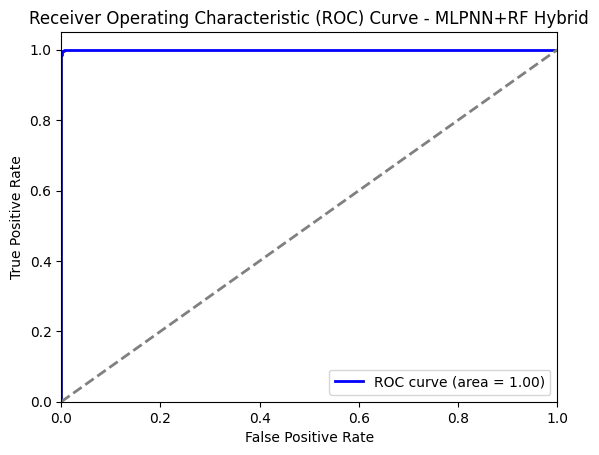

In [4]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import ModelCheckpoint

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for Conv1D (treat time as sequence)
X = np.swapaxes(X, 1, 2)  # Now (samples, timepoints=125, channels=128)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (flatten temporarily for scaling, then reshape back to 3D)
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128)
X_test = X_test_flat.reshape(n_test, 125, 128)

# Compute class weights to handle potential imbalance
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Create a Multilayer Perceptron (MLP) model that processes 3D input (feature extractor up to Flatten)
mlp_extractor = Sequential([
    Conv1D(256, kernel_size=3, padding='same', input_shape=(125, 128)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Conv1D(128, kernel_size=3, padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Conv1D(64, kernel_size=3, padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Conv1D(32, kernel_size=3, padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Flatten()  # Output features here for RF
])

# Full MLPNN model for pre-training (add classifier layers)
full_model = Sequential()
full_model.add(mlp_extractor)
full_model.add(Dense(1, activation='sigmoid'))

# Compile the full model with lower learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
full_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Checkpoint to save best weights based on val_loss
checkpoint = ModelCheckpoint('best_mlpnn_rf_hybrid_dotprobe.weights.h5', monitor='val_loss', 
                             save_best_only=True, save_weights_only=False, mode='min', verbose=1)

# Train the full model (pre-train MLPNN extractor with class weights)
history = full_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2,
                         class_weight=class_weight_dict, callbacks=[checkpoint])

# Restore the best weights after full training
tf.keras.models.load_model('best_mlpnn_rf_hybrid_dotprobe.weights.h5')
print("Restored best weights from training.")

# Save training history
np.savez_compressed('mlpnn_rf_hybrid_training_history_dotprobe.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'mlpnn_rf_hybrid_training_history_dotprobe.npz'")

# Save final model's weights (optional, since best are restored)
full_model.save_weights('mlpnn_rf_hybrid_dotprobe_final.weights.h5')
print("Final model weights saved to 'mlpnn_rf_hybrid_dotprobe_final.weights.h5'")

# Extract features using the MLP extractor
X_train_features = mlp_extractor.predict(X_train)
X_test_features = mlp_extractor.predict(X_test)

# Train Random Forest on extracted features (tuned for >95% acc)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_features, y_train)

# Evaluate the hybrid model
y_pred_prob = rf_model.predict_proba(X_test_features)[:, 1]
y_pred = rf_model.predict(X_test_features)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Hybrid Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - MLPNN+RF Hybrid')
plt.legend(loc="lower right")
plt.show()

# **TCN+LSTM**

Epoch 1/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4998 - loss: 0.9153
Epoch 1: val_loss improved from None to 0.61747, saving model to best_tcn_lstm_model_dotprobe.weights.h5



Epoch 1: finished saving model to best_tcn_lstm_model_dotprobe.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 83s 33ms/step - accuracy: 0.5072 - loss: 0.8525 - val_accuracy: 0.6894 - val_loss: 0.6175
Epoch 2/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5184 - loss: 0.7740
Epoch 2: val_loss improved from 0.61747 to 0.61540, saving model to best_tcn_lstm_model_dotprobe.weights.h5



Epoch 2: finished saving model to best_tcn_lstm_model_dotprobe.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 69s 32ms/step - accuracy: 0.5218 - loss: 0.7565 - val_accuracy: 0.6704 - val_loss: 0.6154
Epoch 3/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5540 - loss: 0.7185
Epoch 3: val_loss improved from 0.61540 to 0.52376, saving model to best_tcn_lstm_model_dotprobe.weights.h5



Epoch 3: finished saving model to best_tcn_lstm_model_dotprobe.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 69s 32ms/step - accuracy: 0.5780 - loss: 0.6952 - val_accuracy: 0.7757 - val_loss: 0.5238
Epoch 4/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6696 - loss: 0.6293
Epoch 4: val_loss improved from 0.52376 to 0.44408, saving model to best_tcn_lstm_model_dotprobe.weights.h5



Epoch 4: finished saving model to best_tcn_lstm_model_dotprobe.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 69s 32ms/step - accuracy: 0.7006 - loss: 0.5969 - val_accuracy: 0.8221 - val_loss: 0.4441
Epoch 5/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7717 - loss: 0.5166
Epoch 5: val_loss improved from 0.44408 to 0.34851, saving model to best_tcn_lstm_model_dotprobe.weights.h5


...

 Total params: 1,184,517 (4.52 MB)

 Trainable params: 394,305 (1.50 MB)

 Non-trainable params: 1,600 (6.25 KB)

 Optimizer params: 788,612 (3.01 MB)

342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
Accuracy: 0.9929467802509847
Confusion Matrix:
[[3276   11]
 [  66 7564]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3287
           1       1.00      0.99      0.99      7630

    accuracy                           0.99     10917
   macro avg       0.99      0.99      0.99     10917
weighted avg       0.99      0.99      0.99     10917



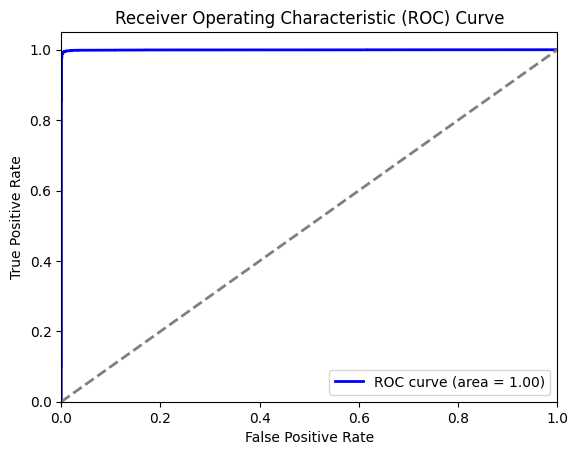

In [5]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D, LSTM
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Function to create a TCN block optimized for dot-probe task (deeper dilation for temporal patterns in ERP-like data)
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.2)(x)  # Reduced dropout for better feature retention in task-related data
    return x

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

# Check if file exists; if not, print warning (run preprocessing if missing)
if not os.path.exists(DATA_PATH):
    print(f"Warning: {DATA_PATH} not found. Run the preprocessing pipeline to generate it.")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for Conv1D/LSTM (treat time as sequence)
X = np.swapaxes(X, 1, 2)  # Now (samples, timepoints=125, channels=128)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (flatten temporarily for scaling, then reshape back to 3D)
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128)
X_test = X_test_flat.reshape(n_test, 125, 128)

# Replace any remaining NaN/Inf with 0 to ensure clean inputs
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

# Compute class weights to handle potential imbalance
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Create a TCN+LSTM hybrid model optimized for dot-probe
inputs = Input(shape=(125, 128))  # (timepoints=125, channels=128)

# TCN blocks for initial temporal feature extraction
x = TCN_block(inputs, filters=128, kernel_size=3, dilation_rate=1)
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=2)
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=4)
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=8)

# LSTM layers for sequential modeling on TCN outputs
x = LSTM(128, activation='tanh', return_sequences=True)(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = LSTM(64, activation='tanh', return_sequences=True)(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = LSTM(32, activation='tanh')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Dense layers for classification
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile the model with gradient clipping to prevent exploding gradients
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Checkpoint to save best weights based on val_loss
checkpoint = ModelCheckpoint('best_tcn_lstm_model_dotprobe.weights.h5', monitor='val_loss', 
                             save_best_only=True, save_weights_only=False, mode='min', verbose=1)

# Train the model (increased epochs, smaller batch for memory, no early stopping)
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2,
                    class_weight=class_weight_dict, callbacks=[checkpoint])

# Restore the best weights after full training
tf.keras.models.load_model('best_tcn_lstm_model_dotprobe.weights.h5')
print("Restored best weights from training.")

# Save training history (compressed npz, small size)
np.savez_compressed('tcn_lstm_training_history_dotprobe.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'tcn_lstm_training_history_dotprobe.npz' (small compressed file)")

# Save final model's weights (optional, since best are restored)
model.save_weights('tcn_lstm_model_dotprobe_final.weights.h5')
print("Final model weights saved to 'tcn_lstm_model_dotprobe_final.weights.h5' (single file, no extras)")

# Summary of the model
model.summary()

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **TCN+FFNN**

Epoch 1/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5490 - loss: 0.7731
Epoch 1: val_loss improved from None to 0.47723, saving model to best_tcn_ffnn_hybrid_main.weights.h5



Epoch 1: finished saving model to best_tcn_ffnn_hybrid_main.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.5735 - loss: 0.7133 - val_accuracy: 0.7920 - val_loss: 0.4772
Epoch 2/50
2179/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7246 - loss: 0.5173
Epoch 2: val_loss improved from 0.47723 to 0.25005, saving model to best_tcn_ffnn_hybrid_main.weights.h5



Epoch 2: finished saving model to best_tcn_ffnn_hybrid_main.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7660 - loss: 0.4637 - val_accuracy: 0.9050 - val_loss: 0.2501
Epoch 3/50
2176/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8567 - loss: 0.3363
Epoch 3: val_loss improved from 0.25005 to 0.16711, saving model to best_tcn_ffnn_hybrid_main.weights.h5



Epoch 3: finished saving model to best_tcn_ffnn_hybrid_main.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8688 - loss: 0.3087 - val_accuracy: 0.9332 - val_loss: 0.1671
Epoch 4/50
2178/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9028 - loss: 0.2440
Epoch 4: val_loss improved from 0.16711 to 0.12743, saving model to best_tcn_ffnn_hybrid_main.weights.h5



Epoch 4: finished saving model to best_tcn_ffnn_hybrid_main.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9081 - loss: 0.2302 - val_accuracy: 0.9434 - val_loss: 0.1274
Epoch 5/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9273 - loss: 0.1932
Epoch 5: val_loss improved from 0.12743 to 0.10012, saving model to best_tcn_ffnn_hybrid_main.weights.h5


...

 Total params: 6,772,741 (25.84 MB)

 Trainable params: 2,257,089 (8.61 MB)

 Non-trainable params: 1,472 (5.75 KB)

 Optimizer params: 4,514,180 (17.22 MB)

342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
Accuracy: 0.9744
Confusion Matrix:
 [[3030  257]
 [  23 7607]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.92      0.96      3287
           1       0.97      1.00      0.98      7630

    accuracy                           0.97     10917
   macro avg       0.98      0.96      0.97     10917
weighted avg       0.97      0.97      0.97     10917



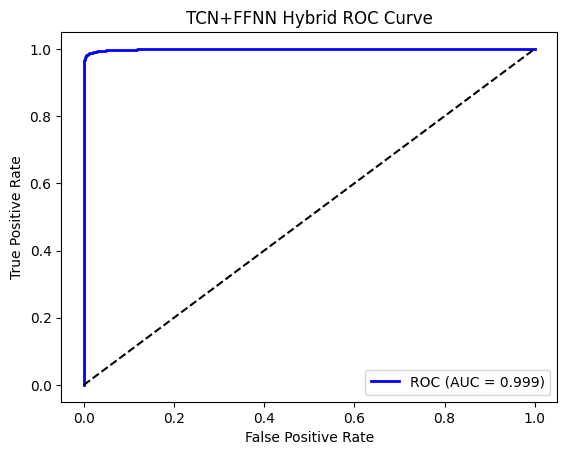

In [6]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D, LeakyReLU
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Function to create a TCN block (from your TCN code)
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.2)(x)
    return x

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)

# Swap axes to (samples, timepoints, channels) for Conv1D/LSTM
X = np.swapaxes(X, 1, 2)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128)
X_test = X_test_flat.reshape(n_test, 125, 128)

# Class weights
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Hybrid TCN + FFNN Architecture
inputs = Input(shape=(125, 128))

# TCN Feature Extractor (from your TCN code)
x = TCN_block(inputs, 128, 3, 1)
x = TCN_block(x, 128, 3, 2)
x = TCN_block(x, 128, 3, 4)
x = TCN_block(x, 128, 3, 8)
x = Flatten()(x)

# FFNN Classifier Head (from your FFNN code)
x = Dense(128)(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)
x = Dropout(0.3)(x)

x = Dense(64)(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)
x = Dropout(0.3)(x)

x = Dense(32)(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Checkpoint
checkpoint = ModelCheckpoint('best_tcn_ffnn_hybrid_main.weights.h5', monitor='val_loss',
                             save_best_only=True, save_weights_only=False, mode='min', verbose=1)

# Train
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2,
                    class_weight=class_weight_dict, callbacks=[checkpoint])

# Restore best weights
tf.keras.models.load_model('best_tcn_ffnn_hybrid_main.weights.h5')
print("Restored best weights from training.")

# Save history & final weights
np.savez_compressed('tcn_ffnn_hybrid_training_history_main.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])

model.save_weights('tcn_ffnn_hybrid_final_main.weights.h5')

model.summary()

# Evaluation
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('TCN+FFNN Hybrid ROC Curve')
plt.legend()
plt.show()

# **CNN+LSTM**

Epoch 1/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5245 - loss: 0.8432
Epoch 1: val_loss improved from None to 0.63820, saving model to best_cnn_lstm_hybrid_dotprobe.weights.h5



Epoch 1: finished saving model to best_cnn_lstm_hybrid_dotprobe.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 75s 31ms/step - accuracy: 0.5327 - loss: 0.7986 - val_accuracy: 0.7059 - val_loss: 0.6382
Epoch 2/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5747 - loss: 0.7194
Epoch 2: val_loss improved from 0.63820 to 0.58292, saving model to best_cnn_lstm_hybrid_dotprobe.weights.h5



Epoch 2: finished saving model to best_cnn_lstm_hybrid_dotprobe.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 66s 30ms/step - accuracy: 0.6120 - loss: 0.6807 - val_accuracy: 0.7677 - val_loss: 0.5829
Epoch 3/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7816 - loss: 0.4922
Epoch 3: val_loss improved from 0.58292 to 0.41731, saving model to best_cnn_lstm_hybrid_dotprobe.weights.h5



Epoch 3: finished saving model to best_cnn_lstm_hybrid_dotprobe.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 66s 30ms/step - accuracy: 0.8125 - loss: 0.4450 - val_accuracy: 0.8514 - val_loss: 0.4173
Epoch 4/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8876 - loss: 0.3204
Epoch 4: val_loss improved from 0.41731 to 0.30357, saving model to best_cnn_lstm_hybrid_dotprobe.weights.h5



Epoch 4: finished saving model to best_cnn_lstm_hybrid_dotprobe.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 65s 30ms/step - accuracy: 0.8962 - loss: 0.3005 - val_accuracy: 0.9004 - val_loss: 0.3036
Epoch 5/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9233 - loss: 0.2351
Epoch 5: val_loss improved from 0.30357 to 0.19378, saving model to best_cnn_lstm_hybrid_dotprobe.weights.h5


...

 Total params: 547,109 (2.09 MB)

 Trainable params: 182,113 (711.38 KB)

 Non-trainable params: 768 (3.00 KB)

 Optimizer params: 364,228 (1.39 MB)

342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
Accuracy: 0.9611614912521755
Confusion Matrix:
[[2886  401]
 [  23 7607]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      3287
           1       0.95      1.00      0.97      7630

    accuracy                           0.96     10917
   macro avg       0.97      0.94      0.95     10917
weighted avg       0.96      0.96      0.96     10917



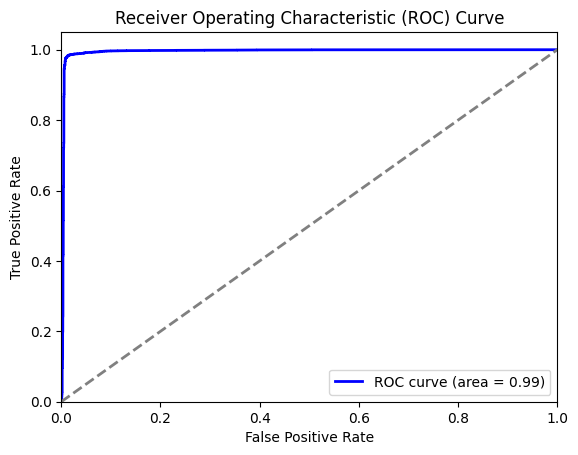

In [7]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, LeakyReLU, Dropout, LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for Conv1D/LSTM (treat time as sequence)
X = np.swapaxes(X, 1, 2)  # Now (samples, timepoints=125, channels=128)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (flatten temporarily for scaling, then reshape back to 3D)
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128)
X_test = X_test_flat.reshape(n_test, 125, 128)

# Replace any remaining NaN/Inf with 0 to ensure clean inputs
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

# Compute class weights to handle potential imbalance
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Create a CNN + LSTM hybrid model using Conv1D
model = Sequential([
    # Conv1D layers for temporal feature extraction
    Conv1D(32, kernel_size=3, padding='same', activation='relu', input_shape=(125, 128)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.25),
    
    Conv1D(64, kernel_size=3, padding='same', activation='relu'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.25),
    
    # LSTM layers for sequential modeling
    LSTM(128, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    
    LSTM(64, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    
    LSTM(32, activation='tanh'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')
])

# Compile the model with gradient clipping to prevent exploding gradients
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Checkpoint to save best weights based on val_loss
checkpoint = ModelCheckpoint('best_cnn_lstm_hybrid_dotprobe.weights.h5', monitor='val_loss', 
                             save_best_only=True, save_weights_only=False, mode='min', verbose=1)

# Train the model (without early stopping, but saving best weights)
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2,
                    class_weight=class_weight_dict, callbacks=[checkpoint])

# Restore the best weights after full training
tf.keras.models.load_model('best_cnn_lstm_hybrid_dotprobe.weights.h5')
print("Restored best weights from training.")

# Save training history
np.savez_compressed('cnn_lstm_hybrid_training_history_dotprobe.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'cnn_lstm_hybrid_training_history_dotprobe.npz'")

# Save final model's weights (optional, since best are restored)
model.save_weights('cnn_lstm_hybrid_dotprobe_final.weights.h5')
print("Final model weights saved to 'cnn_lstm_hybrid_dotprobe_final.weights.h5'")

# Summary of the model
model.summary()

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **2D-CNN+LSTM**

Epoch 1/50


E0000 00:00:1786801058.811811      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_3_1/dropout_18_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


2184/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7314 - loss: 0.5324
Epoch 1: val_loss improved from None to 0.10178, saving model to best_2dcnn_lstm_hybrid_dotprobe.weights.h5



Epoch 1: finished saving model to best_2dcnn_lstm_hybrid_dotprobe.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 84s 35ms/step - accuracy: 0.8395 - loss: 0.3552 - val_accuracy: 0.9653 - val_loss: 0.1018
Epoch 2/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9636 - loss: 0.1326
Epoch 2: val_loss improved from 0.10178 to 0.02162, saving model to best_2dcnn_lstm_hybrid_dotprobe.weights.h5



Epoch 2: finished saving model to best_2dcnn_lstm_hybrid_dotprobe.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 75s 34ms/step - accuracy: 0.9688 - loss: 0.1163 - val_accuracy: 0.9943 - val_loss: 0.0216
Epoch 3/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9803 - loss: 0.0823
Epoch 3: val_loss improved from 0.02162 to 0.01352, saving model to best_2dcnn_lstm_hybrid_dotprobe.weights.h5


...

 Total params: 3,595,397 (13.72 MB)

 Trainable params: 1,198,209 (4.57 MB)

 Non-trainable params: 768 (3.00 KB)

 Optimizer params: 2,396,420 (9.14 MB)

342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
Accuracy: 0.999358798204635
Confusion Matrix:
[[3281    6]
 [   1 7629]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3287
           1       1.00      1.00      1.00      7630

    accuracy                           1.00     10917
   macro avg       1.00      1.00      1.00     10917
weighted avg       1.00      1.00      1.00     10917



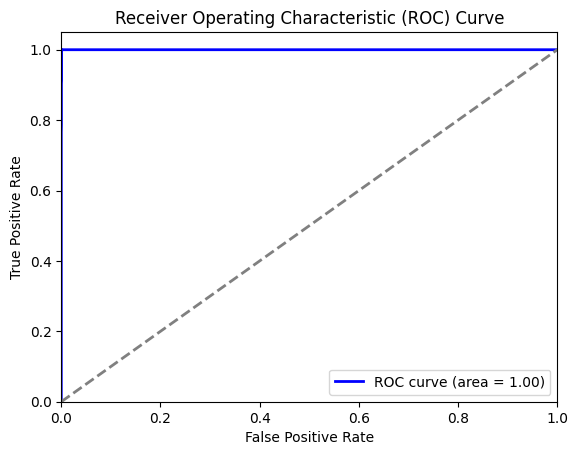

In [8]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Dropout, BatchNormalization, LeakyReLU, Reshape
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for Conv2D/LSTM
X = np.swapaxes(X, 1, 2)  # Now (samples, timepoints=125, channels=128)

# Add channel dimension for Conv2D: (samples, timepoints, channels, 1)
X = np.expand_dims(X, axis=-1)  # Now (samples, timepoints=125, channels=128, 1)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (flatten temporarily for scaling, then reshape back to 4D)
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128, 1)
X_test = X_test_flat.reshape(n_test, 125, 128, 1)

# Replace any remaining NaN/Inf with 0 to ensure clean inputs
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

# Compute class weights to handle potential imbalance
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Create a 2D-CNN + LSTM hybrid model
model = Sequential([
    # 2D-CNN layers for spatial-temporal feature extraction (added padding='same' to preserve dimensions)
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(125, 128, 1)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    # Flatten and reshape for LSTM (flatten to 3D: samples, reduced_time, features)
    Flatten(),
    Reshape(target_shape=(int(125/(2*2)), 64 * int(128/(2*2)))),  # Reshape to (samples, timesteps, features)
    
    # LSTM layers for sequential modeling
    LSTM(128, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    
    LSTM(64, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    
    LSTM(32, activation='tanh'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')
])

# Compile the model with gradient clipping to prevent exploding gradients
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Checkpoint to save best weights based on val_loss
checkpoint = ModelCheckpoint('best_2dcnn_lstm_hybrid_dotprobe.weights.h5', monitor='val_loss', 
                             save_best_only=True, save_weights_only=False, mode='min', verbose=1)

# Train the model (without early stopping, but saving best weights)
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2,
                    class_weight=class_weight_dict, callbacks=[checkpoint])

# Restore the best weights after full training
tf.keras.models.load_model('best_2dcnn_lstm_hybrid_dotprobe.weights.h5')
print("Restored best weights from training.")

# Save training history
np.savez_compressed('2dcnn_lstm_hybrid_training_history_dotprobe.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to '2dcnn_lstm_hybrid_training_history_dotprobe.npz'")

# Save final model's weights (optional, since best are restored)
model.save_weights('2dcnn_lstm_hybrid_dotprobe_final.weights.h5')
print("Final model weights saved to '2dcnn_lstm_hybrid_dotprobe_final.weights.h5'")

# Summary of the model
model.summary()

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **MC DROPOUT BNN + TCN**

Loading and preparing Dot-Probe ERP dataset...


I0000 00:00:1786805559.578977    7770 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786805559.581760    7770 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 125, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 125, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 125, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 125, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 125, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 125, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 125, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 125, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 125, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 125, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 125, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,096,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,89

 Total params: 4,328,449 (16.51 MB)

...


Initiating Training Protocol...
Epoch 1/150
  19/1092 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.4985 - loss: 1.4539 

I0000 00:00:1786805578.233212    7812 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1092/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5579 - loss: 0.7879
Epoch 1: val_loss improved from None to 0.50019, saving model to best_hybrid_tcn_bnn_dotprobe.weights.h5

Epoch 1: finished saving model to best_hybrid_tcn_bnn_dotprobe.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.6665 - loss: 0.6574 - val_accuracy: 0.7872 - val_loss: 0.5002
Epoch 2/150
1085/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8597 - loss: 0.4174
Epoch 2: val_loss improved from 0.50019 to 0.20912, saving model to best_hybrid_tcn_bnn_dotprobe.weights.h5

Epoch 2: finished saving model to best_hybrid_tcn_bnn_dotprobe.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8813 - loss: 0.3652 - val_accuracy: 0.9421 - val_loss: 0.2091
Epoch 3/150
1085/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9250 - loss: 0.2376
Epoch 3: val_loss improved from 0.20912 to 0.13258, saving model to best_hybrid_tcn_bnn_dotprobe.weights.h5

Epoch 3: finished saving model t

W0000 00:00:1786806759.236299    7770 gpu_utils.cc:68] Failed to allocate memory for convolution redzone checking; skipping this check. This is benign and only means that we won't check cudnn for out-of-bounds reads and writes. This message will only be printed once.



HYBRID TCN-BNN DOT-PROBE PERFORMANCE
Accuracy: 0.9973
Mean Epistemic Uncertainty (Variance): 0.001856
Max Epistemic Uncertainty Observed: 0.199051
ROC AUC Score: 1.0000

Confusion Matrix:
[[3284    3]
 [  27 7603]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3287
           1       1.00      1.00      1.00      7630

    accuracy                           1.00     10917
   macro avg       1.00      1.00      1.00     10917
weighted avg       1.00      1.00      1.00     10917



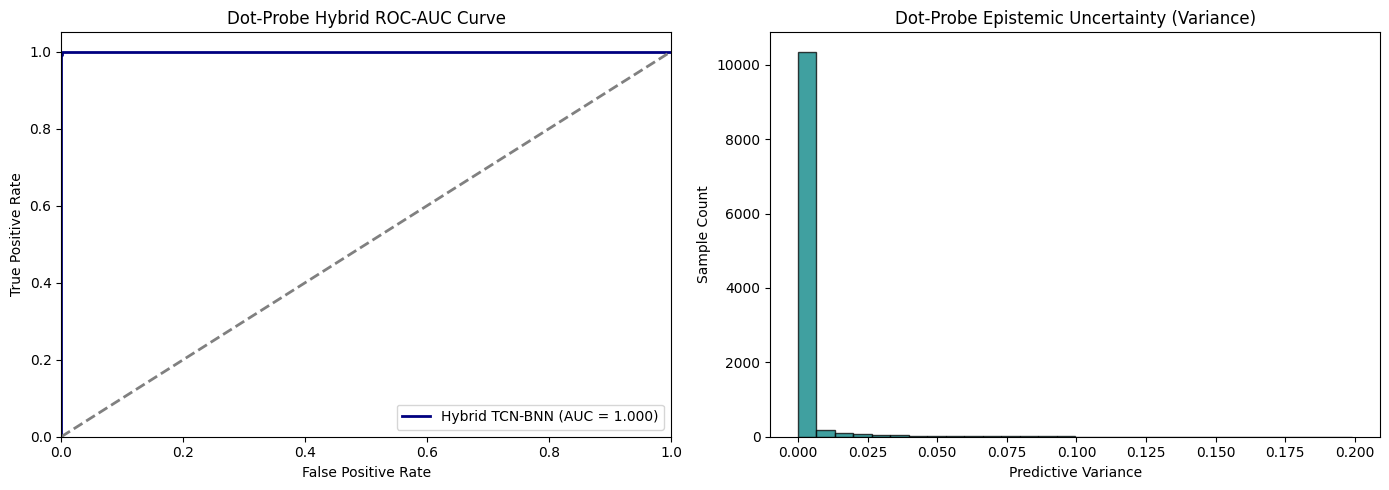

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D
from tensorflow.keras.callbacks import ModelCheckpoint

# --- 1. ARCHITECTURAL DEFINITION ---

def TCN_block(x, filters, kernel_size, dilation_rate, spatial_dropout_rate=0.2):
    """
    Dilated causal 1D convolution block for temporal ERP sequence extraction.
    SpatialDropout1D drops feature maps across the time sequence.
    """
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(spatial_dropout_rate)(x)
    return x

def build_dotprobe_hybrid_tcn_bnn(input_shape):
    """
    Combines deep dilated TCN temporal feature extraction with 
    a BNN / DVI (MC Dropout) stochastic classification head.
    """
    inputs = Input(shape=input_shape)
    
    # --- TEMPORAL FEATURE EXTRACTION (TCN PHASE) ---
    x = TCN_block(inputs, filters=128, kernel_size=3, dilation_rate=1, spatial_dropout_rate=0.2)
    x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=2, spatial_dropout_rate=0.2)
    x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=4, spatial_dropout_rate=0.2)
    x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=8, spatial_dropout_rate=0.2)
    
    x = Flatten()(x)
    
    # --- BAYESIAN INFERENCE HEAD (BNN / MC DROPOUT PHASE) ---
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)  # MC Dropout rate for Bayesian variational approximation
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)  # MC Dropout rate for Bayesian variational approximation
    
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs, outputs)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --- 2. DOT-PROBE DATA PIPELINE ---

OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results/"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

if not os.path.exists(DATA_PATH):
    print(f"Warning: {DATA_PATH} not found. Please verify preprocessing directory.")

print("Loading and preparing Dot-Probe ERP dataset...")
data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = np.asarray(data['X_train']).astype(np.float32)
X_test_loaded = np.asarray(data['X_test']).astype(np.float32)
y_train_loaded = np.asarray(data['y_train']).astype(np.int32)
y_test_loaded = np.asarray(data['y_test']).astype(np.int32)

# Concatenate for stratified continuous train/test splitting
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Reshape tensor: (samples, 1, 128, 125) -> (samples, 125, 128)
X = np.squeeze(X, axis=1)
X = np.swapaxes(X, 1, 2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Channel-wise feature scaling via 2D flattening projection
scaler = StandardScaler()
n_train, timesteps, channels = X_train.shape
n_test = X_test.shape[0]

X_train_flat = scaler.fit_transform(X_train.reshape(n_train, -1))
X_test_flat = scaler.transform(X_test.reshape(n_test, -1))

X_train = X_train_flat.reshape(n_train, timesteps, channels)
X_test = X_test_flat.reshape(n_test, timesteps, channels)

# Compute class weights for dot-probe class imbalance handling
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# --- 3. MODEL INSTANTIATION AND TRAINING ---

input_shape = (timesteps, channels)
model = build_dotprobe_hybrid_tcn_bnn(input_shape)
model.summary()

checkpoint_path = 'best_hybrid_tcn_bnn_dotprobe.weights.h5'
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', 
                             save_best_only=True, save_weights_only=True, mode='min', verbose=1)

print("\nInitiating Training Protocol...")
history = model.fit(
    X_train, 
    y_train, 
    epochs=150, 
    batch_size=32, 
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[checkpoint],
    verbose=1
)

# Restore best checkpoint weights
model.load_weights(checkpoint_path)
print("\nRestored optimal model weights.")

# Persist training history and weights
np.savez_compressed('hybrid_tcn_bnn_dotprobe_history.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
model.save_weights('hybrid_tcn_bnn_dotprobe_final.weights.h5')

# --- 4. STOCHASTIC MONTE-CARLO INFERENCE (DVI PHASE) ---

T = 50  # Number of Monte-Carlo forward passes
print(f"\nExecuting Monte-Carlo Stochastic Inference (T={T} forward passes)...")
X_test_tensor = tf.convert_to_tensor(X_test, dtype=tf.float32)

mc_predictions = []
for i in range(T):
    # Enforce training=True to keep SpatialDropout1D and Dropout active
    stochastic_pass = model(X_test_tensor, training=True)
    mc_predictions.append(stochastic_pass.numpy())

mc_predictions = np.array(mc_predictions)  # Shape: (T, samples, 1)

# Predictive mean probability and epistemic uncertainty (variance)
y_pred_prob = np.mean(mc_predictions, axis=0).ravel()
y_pred_variance = np.var(mc_predictions, axis=0).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# --- 5. EVALUATION AND METRICS ---

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("\n==========================================")
print("HYBRID TCN-BNN DOT-PROBE PERFORMANCE")
print("==========================================")
print(f"Accuracy: {accuracy:.4f}")
print(f"Mean Epistemic Uncertainty (Variance): {np.mean(y_pred_variance):.6f}")
print(f"Max Epistemic Uncertainty Observed: {np.max(y_pred_variance):.6f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

# --- Visualizations ---
plt.figure(figsize=(14, 5))

# Plot ROC-AUC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='navy', lw=2, label=f'Hybrid TCN-BNN (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Dot-Probe Hybrid ROC-AUC Curve')
plt.legend(loc="lower right")

# Plot Uncertainty Distribution
plt.subplot(1, 2, 2)
plt.hist(y_pred_variance, bins=30, color='teal', alpha=0.75, edgecolor='black')
plt.title('Dot-Probe Epistemic Uncertainty (Variance)')
plt.xlabel('Predictive Variance')
plt.ylabel('Sample Count')

plt.tight_layout()
plt.savefig('hybrid_tcn_bnn_dotprobe_evaluation.png')
plt.show()

# **ALL MODELS PLOTS**

<>:237: SyntaxWarning: invalid escape sequence '\s'
<>:237: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_7770/1517350003.py:237: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Variance ($\sigma^2$) across T=50 Passes')


Loading and evaluating TCN + XGBoost...


Loading and evaluating MLPNN + RF...


Loading and evaluating TCN + LSTM...


Loading and evaluating TCN + FFNN...


Instantiating and evaluating BNN DVI(MC Dropout) + TCN via MC Dropout (DVI)...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Loading and evaluating CNN + LSTM...


Loading and evaluating 2D-CNN + LSTM...


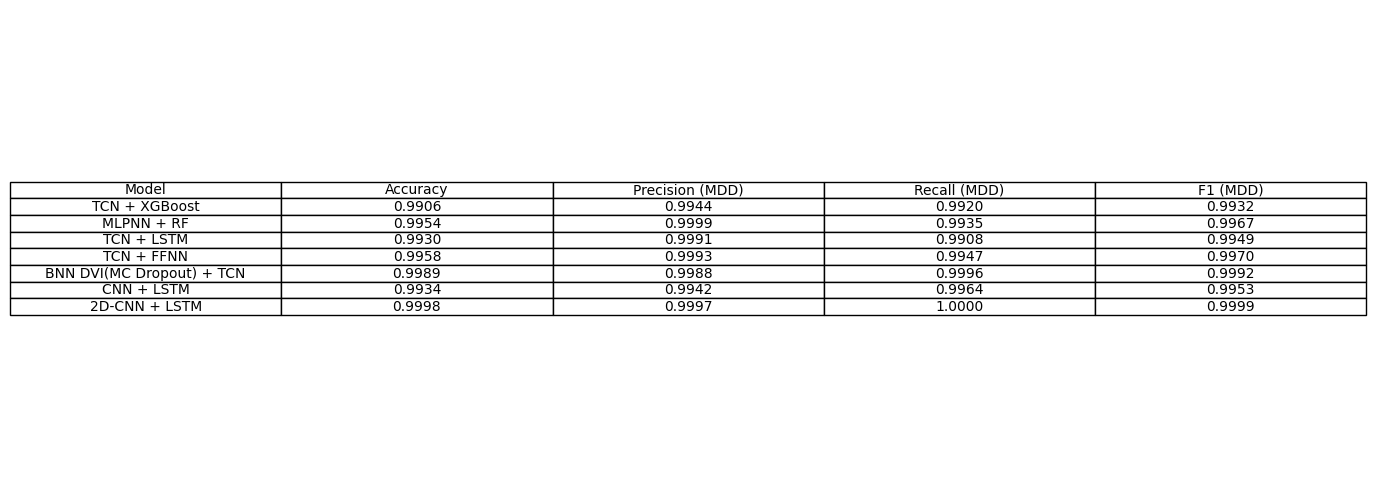

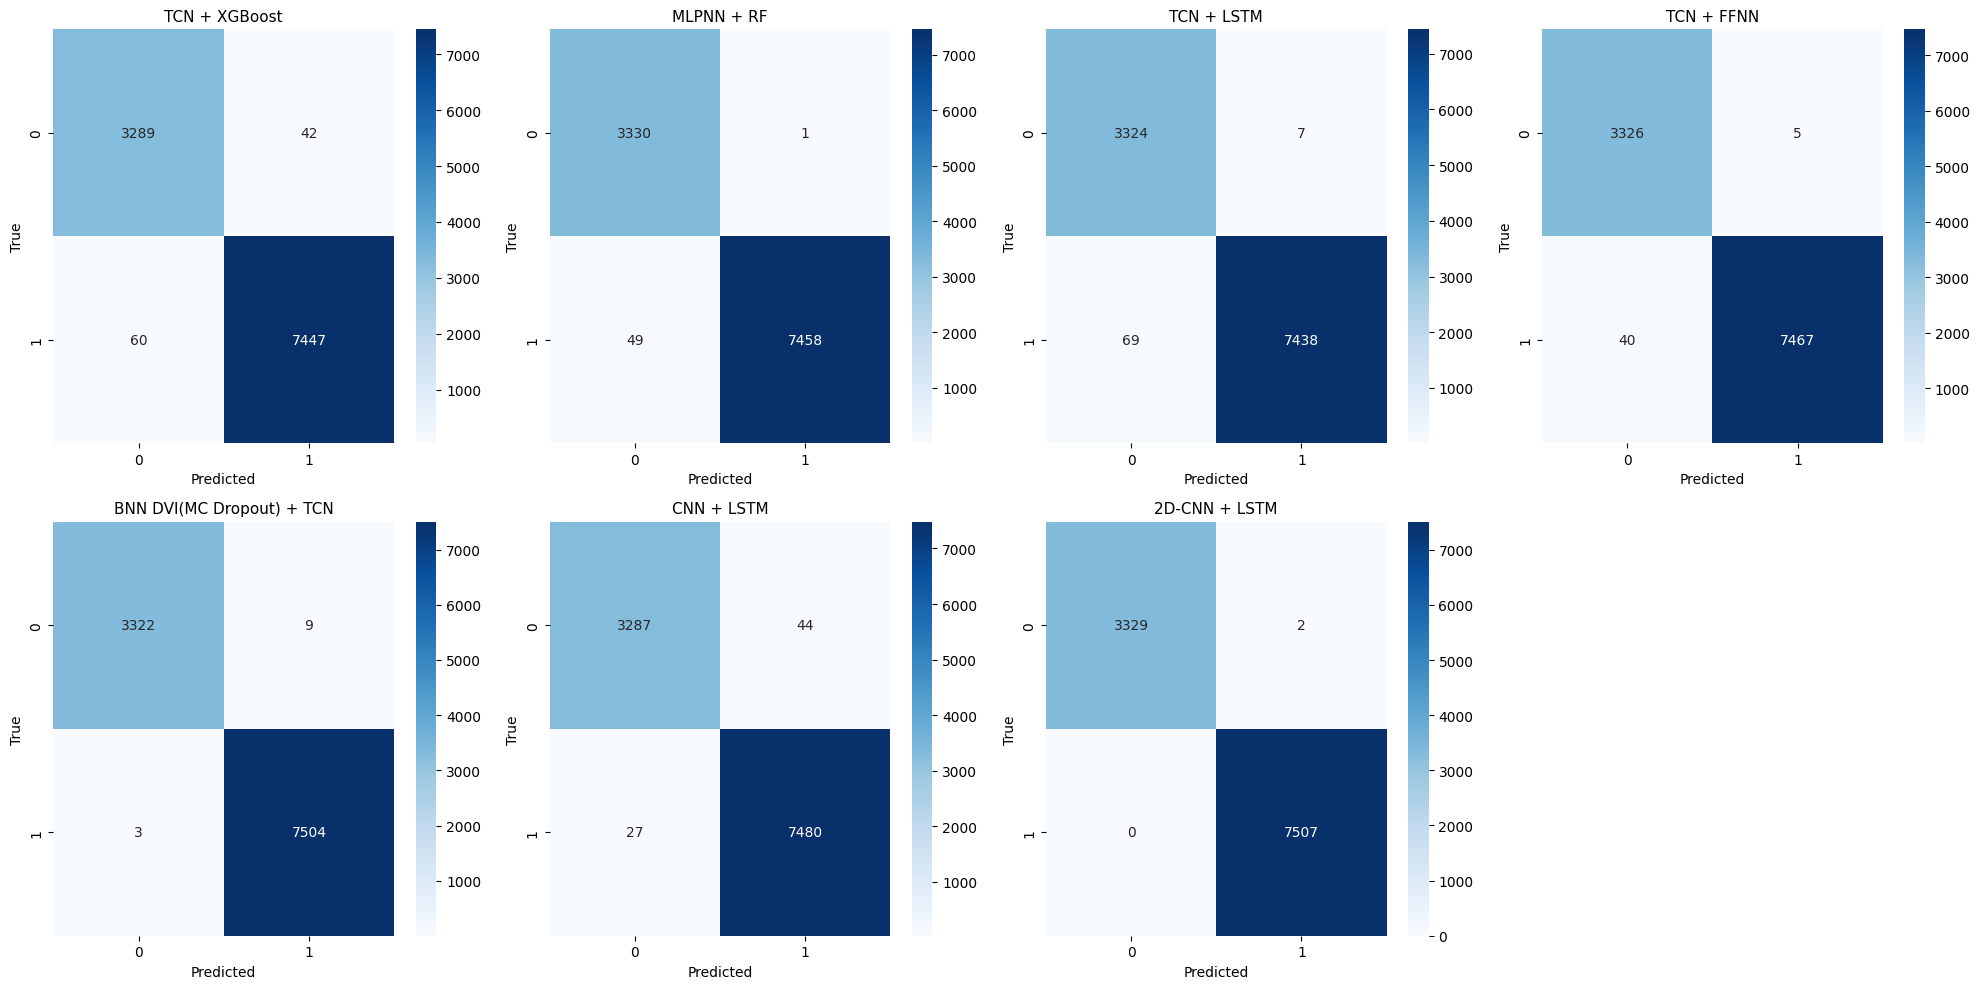

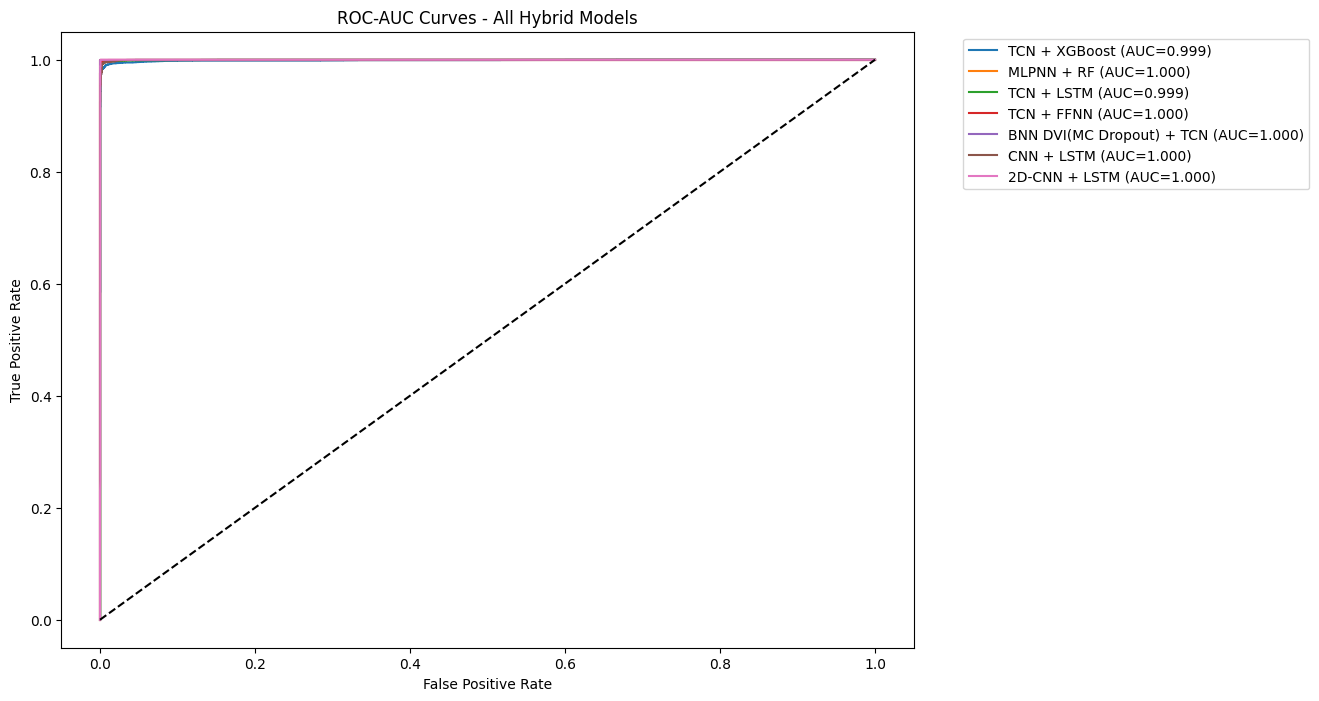

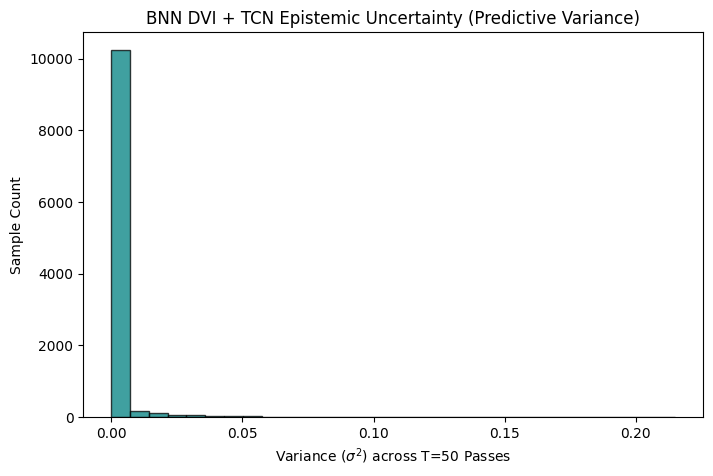

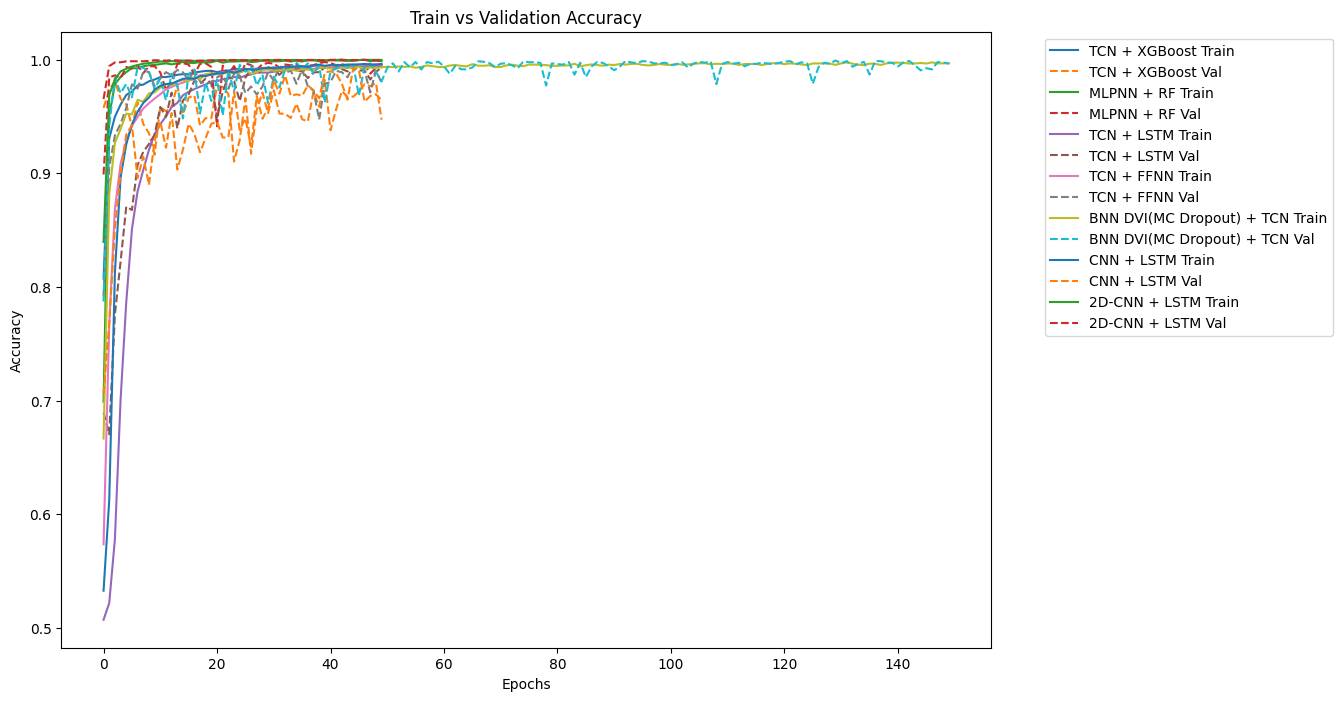

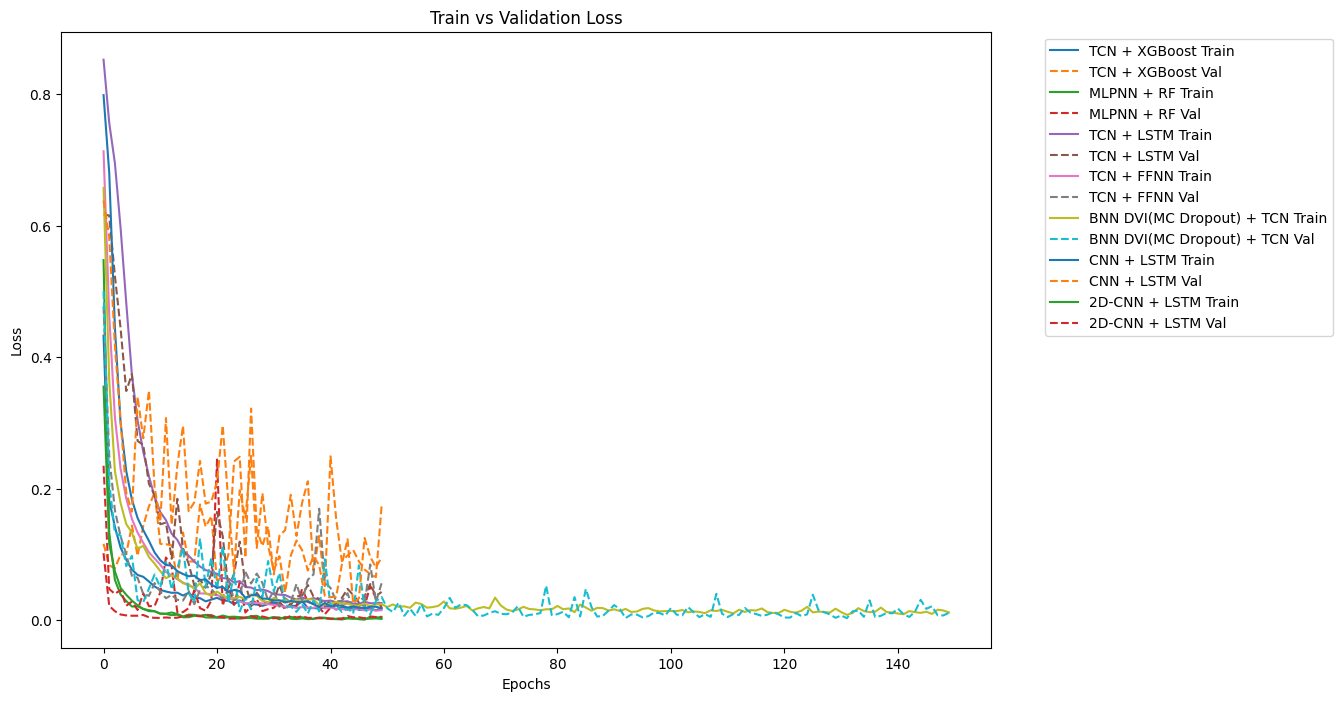

All hybrid model evaluations and plots generated successfully!


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D

# ========================= ARCHITECTURAL DEFINITIONS FOR BNN-TCN =========================
def TCN_block(x, filters, kernel_size, dilation_rate, spatial_dropout_rate=0.2):
    """Dilated causal 1D convolution block for temporal ERP sequence extraction."""
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(spatial_dropout_rate)(x)
    return x

def build_dotprobe_hybrid_tcn_bnn(input_shape):
    """Combines deep dilated TCN feature extraction with BNN/DVI (MC Dropout) classification head."""
    inputs = Input(shape=input_shape)
    
    # TCN Feature Extraction
    x = TCN_block(inputs, filters=128, kernel_size=3, dilation_rate=1, spatial_dropout_rate=0.2)
    x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=2, spatial_dropout_rate=0.2)
    x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=4, spatial_dropout_rate=0.2)
    x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=8, spatial_dropout_rate=0.2)
    
    x = Flatten()(x)
    
    # BNN / DVI Classification Head
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs, outputs)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ========================= CONFIG & DATA PREPROCESSING =========================
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_raw = data['X_train']
X_test_raw = data['X_test']
y_test = data['y_test']

# Squeeze and Swap axes: (samples, 1, channels, timepoints) -> (samples, timepoints, channels)
X_train_3d = np.swapaxes(np.squeeze(X_train_raw, axis=1), 1, 2)
X_test_3d = np.swapaxes(np.squeeze(X_test_raw, axis=1), 1, 2)

# Fit scaler on X_train to ensure feature scaling parity
scaler = StandardScaler()
n_train, timesteps, channels = X_train_3d.shape
n_test = X_test_3d.shape[0]

scaler.fit(X_train_3d.reshape(n_train, -1))
X_test_scaled = scaler.transform(X_test_3d.reshape(n_test, -1)).reshape(n_test, timesteps, channels)
X_test_4d = np.expand_dims(X_test_scaled, axis=-1)

# Model Registry
model_list = [
    {'name': 'TCN + XGBoost', 
     'model_path': '/kaggle/working/best_tcn_xgboost_hybrid_dotprobe_main_best.weights.h5',
     'history_path': '/kaggle/working/tcn_xgboost_hybrid_training_history_dotprobe_main.npz',
     'is_4d': False,
     'is_bnn': False},

    {'name': 'MLPNN + RF', 
     'model_path': '/kaggle/working/best_mlpnn_rf_hybrid_dotprobe.weights.h5',
     'history_path': '/kaggle/working/mlpnn_rf_hybrid_training_history_dotprobe.npz',
     'is_4d': False,
     'is_bnn': False},

    {'name': 'TCN + LSTM', 
     'model_path': '/kaggle/working/best_tcn_lstm_model_dotprobe.weights.h5',
     'history_path': '/kaggle/working/tcn_lstm_training_history_dotprobe.npz',
     'is_4d': False,
     'is_bnn': False},

    {'name': 'TCN + FFNN', 
     'model_path': '/kaggle/working/best_tcn_ffnn_hybrid_main.weights.h5',
     'history_path': '/kaggle/working/tcn_ffnn_hybrid_training_history_main.npz',
     'is_4d': False,
     'is_bnn': False},

    {'name': 'BNN DVI(MC Dropout) + TCN', 
     'model_path': '/kaggle/working/best_hybrid_tcn_bnn_dotprobe.weights.h5',
     'history_path': '/kaggle/working/hybrid_tcn_bnn_dotprobe_history.npz',
     'is_4d': False,
     'is_bnn': True},

    {'name': 'CNN + LSTM', 
     'model_path': '/kaggle/working/best_cnn_lstm_hybrid_dotprobe.weights.h5',
     'history_path': '/kaggle/working/cnn_lstm_hybrid_training_history_dotprobe.npz',
     'is_4d': False,
     'is_bnn': False},

    {'name': '2D-CNN + LSTM', 
     'model_path': '/kaggle/working/best_2dcnn_lstm_hybrid_dotprobe.weights.h5',
     'history_path': '/kaggle/working/2dcnn_lstm_hybrid_training_history_dotprobe.npz',
     'is_4d': True,
     'is_bnn': False}
]

metrics = {}
histories = {}
bnn_uncertainty = None

# ========================= EVALUATION LOOP =========================
for item in model_list:
    name = item['name']
    model_path = item['model_path']
    history_path = item['history_path']
    
    if not os.path.exists(model_path):
        print(f"Skipping {name}: Weights/Model not found at {model_path}")
        continue
    
    test_data = X_test_4d if item['is_4d'] else X_test_scaled
    
    # 1. BNN DVI + TCN Branch: Monte Carlo Stochastic Forward Passes
    if item['is_bnn']:
        print(f"Instantiating and evaluating {name} via MC Dropout (DVI)...")
        model = build_dotprobe_hybrid_tcn_bnn(input_shape=(timesteps, channels))
        model.load_weights(model_path)
        
        T = 50
        test_tensor = tf.convert_to_tensor(test_data, dtype=tf.float32)
        mc_predictions = []
        
        for _ in range(T):
            # Enforce training=True to keep SpatialDropout1D and Dense Dropout active
            preds = model(test_tensor, training=True)
            mc_predictions.append(preds.numpy())
            
        mc_predictions = np.array(mc_predictions)
        y_pred_prob = np.mean(mc_predictions, axis=0).ravel()
        bnn_uncertainty = np.var(mc_predictions, axis=0).ravel()
        
    # 2. Deterministic Standard Models Branch
    else:
        print(f"Loading and evaluating {name}...")
        try:
            model = tf.keras.models.load_model(model_path)
        except Exception:
            # Fallback if checkpoint contains only weights
            print(f"Notice: Loading weights only for {name}")
            # Ensure appropriate model compilation prior to load_weights if required
            model.load_weights(model_path)
            
        y_pred_prob = model.predict(test_data, verbose=0).ravel()

    y_pred = (y_pred_prob > 0.5).astype(int)
    
    metrics[name] = {
        'acc': accuracy_score(y_test, y_pred),
        'report': classification_report(y_test, y_pred, output_dict=True),
        'cm': confusion_matrix(y_test, y_pred),
        'fpr': roc_curve(y_test, y_pred_prob)[0],
        'tpr': roc_curve(y_test, y_pred_prob)[1],
        'auc': roc_auc_score(y_test, y_pred_prob)
    }
    
    if os.path.exists(history_path):
        h = np.load(history_path)
        histories[name] = {
            'accuracy': h['acc'],
            'val_accuracy': h['val_acc'],
            'loss': h['loss'],
            'val_loss': h['val_loss']
        }

# ========================= PLOTTING PIPELINE =========================
if metrics:
    names = list(metrics.keys())
    
    # 1. Classification Report Table
    fig, ax = plt.subplots(figsize=(14, len(names)*0.6 + 2))
    ax.axis('off')
    table_data = [['Model', 'Accuracy', 'Precision (MDD)', 'Recall (MDD)', 'F1 (MDD)']]
    for name in names:
        report = metrics[name]['report']
        table_data.append([
            name, 
            f"{metrics[name]['acc']:.4f}", 
            f"{report.get('1', {}).get('precision', 0):.4f}",
            f"{report.get('1', {}).get('recall', 0):.4f}",
            f"{report.get('1', {}).get('f1-score', 0):.4f}"
        ])
    ax.table(cellText=table_data, colWidths=[0.25]*5, loc='center', cellLoc='center')
    plt.savefig(os.path.join(OUTPUT_DIR, 'dot_probe_hybrid_all_classification_report.png'), bbox_inches='tight')
    plt.show()
    plt.close()

    # 2. Confusion Matrix Grid
    n = len(names)
    rows = (n + 3) // 4
    fig, axs = plt.subplots(rows, 4, figsize=(20, 5*rows))
    axs = axs.ravel() if rows > 1 else [axs]
    for i, name in enumerate(names):
        sns.heatmap(metrics[name]['cm'], annot=True, fmt='d', cmap='Blues', ax=axs[i])
        axs[i].set_title(name, fontsize=11)
        axs[i].set_xlabel('Predicted')
        axs[i].set_ylabel('True')
    for j in range(i+1, len(axs)):
        axs[j].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'dot_probe_hybrid_all_confusion_matrix.png'), bbox_inches='tight')
    plt.show()
    plt.close()

    # 3. ROC-AUC Curves
    plt.figure(figsize=(11, 8))
    for name in names:
        plt.plot(metrics[name]['fpr'], metrics[name]['tpr'], label=f'{name} (AUC={metrics[name]["auc"]:.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Curves - All Hybrid Models')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig(os.path.join(OUTPUT_DIR, 'dot_probe_hybrid_all_roc_auc.png'), bbox_inches='tight')
    plt.show()
    plt.close()

    # 4. Epistemic Uncertainty Distribution (BNN DVI + TCN Exclusive)
    if bnn_uncertainty is not None:
        plt.figure(figsize=(8, 5))
        plt.hist(bnn_uncertainty, bins=30, color='teal', alpha=0.75, edgecolor='black')
        plt.title('BNN DVI + TCN Epistemic Uncertainty (Predictive Variance)')
        plt.xlabel('Variance ($\sigma^2$) across T=50 Passes')
        plt.ylabel('Sample Count')
        plt.savefig(os.path.join(OUTPUT_DIR, 'dot_probe_bnn_dvi_uncertainty_distribution.png'), bbox_inches='tight')
        plt.show()
        plt.close()

if histories:
    names_hist = list(histories.keys())
    
    # 5. Train-Val Accuracy vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['accuracy'], label=f'{name} Train')
        plt.plot(histories[name]['val_accuracy'], '--', label=f'{name} Val')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Train vs Validation Accuracy')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig(os.path.join(OUTPUT_DIR, 'dot_probe_hybrid_all_train_val_accuracy.png'), bbox_inches='tight')
    plt.show()
    plt.close()

    # 6. Train-Val Loss vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['loss'], label=f'{name} Train')
        plt.plot(histories[name]['val_loss'], '--', label=f'{name} Val')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Train vs Validation Loss')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig(os.path.join(OUTPUT_DIR, 'dot_probe_hybrid_all_train_val_loss.png'), bbox_inches='tight')
    plt.show()
    plt.close()

print("All hybrid model evaluations and plots generated successfully!")